# Histogram Equalization / Égalisation de l'histogramme

### Upload packages / importer les packages 

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### chargement d'image 

Images dimension / Les dimension de l'image :  (576, 768)
image height / L'hauteur de l'image :  576
Image width / Largeur de l'image : 768


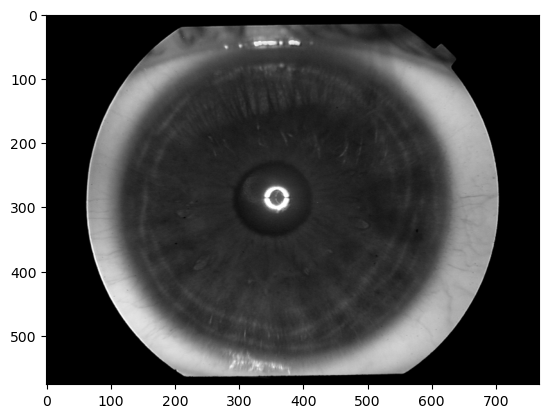

In [2]:
## 0 for reading the image in grayscale mode
img = cv.imread('001L_1.png',0)
## Image dimension / dimension de l'image
dimensions = img.shape
print("Images dimension / Les dimension de l'image : ", dimensions)
## Image width and height / largeur et hauteur de l'image
height = img.shape[0]
width = img.shape[1]
print("image height / L'hauteur de l'image : ",height)
print("Image width / Largeur de l'image :",width)
## Display image / Affichage de l'image
plt.imshow(img, cmap=plt.get_cmap('gray'))

## Histogram / Histogramme : 

### Function to manually compute the histogram / fonction qui calcule l'histogramme manuallement :



formule mathématique pour calculer l'histogramme est :
$$ P_{x}(j)=\sum_{i=0}^{j}P_{x}(j)$$

In [3]:
## Function to manually compute the histogram / Fonction qui calcule l'histogramme manuellement
def Hist(img):
    # Image dimensions: m = number of rows, n = number of columns
    # dimensione de l'image m=nbr de ligne n =nbr de colonne
    m, n = img.shape 
    hist = np.zeros((256), dtype=int)
     #calculer histogramme
    for i in range(0,m):
        for j in range(0,n):
            hist[img[i,j]] += 1
    return hist 

## Display / affichage

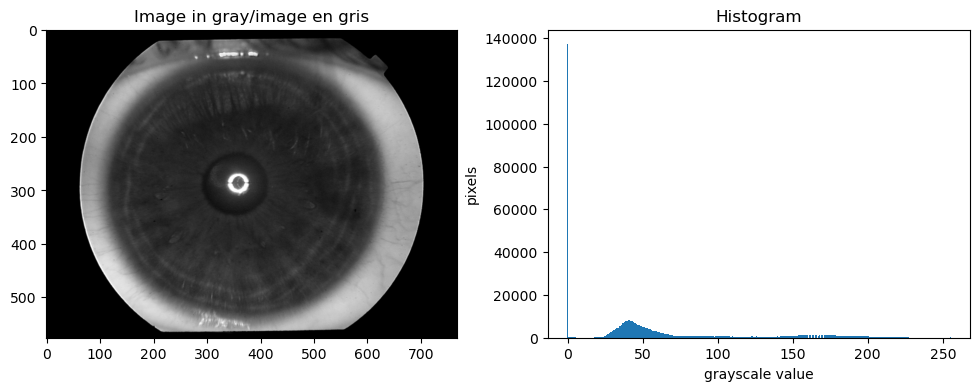

In [4]:
_, axis = plt.subplots(ncols=2, figsize=(12, 4))
axis[0].imshow(img, cmap=plt.get_cmap('gray'))
axis[1].set_title('Histogram')
axis[0].set_title('Image in gray/image en gris')
hist=Hist(img)
#Display histogram with matplotlib / affichage de l'histogramme a l'aide de matplotlib
plt.bar(np.arange(0,256), hist,width = 0.99)
plt.xlabel("grayscale value")
plt.ylabel("pixels")
axis[1].plot()
plt.show()

## Cumlative histogram of an image / L’histogramme cumulé d’une image   :
The cumulative histogram of an image:
We need the concept of the cumulative histogram, which measures the cumulative distribution of gray levels in an image. For a gray level x, the cumulative histogram allows us to determine the probability of finding a pixel with a value less than or equal to x when randomly selecting a pixel from the image. The cumulative histogram is therefore easily calculated from the histogram.

nous avons besoin de la notion d’histogramme cumulé qui mesure la distribution cumulée des niveaux de gris dans une image. Pour un niveau de gris x, l’histogramme cumulé permet de connaitre la probabilité de tomber sur un pixel de valeur inférieure ou égale à x en tirant un pixel au hasard dans l’image.
L’histogramme cumulé se calcule donc simplement à partir de l’histogramme.

In [5]:
def cumsum(histogram):
    return histogram.cumsum()

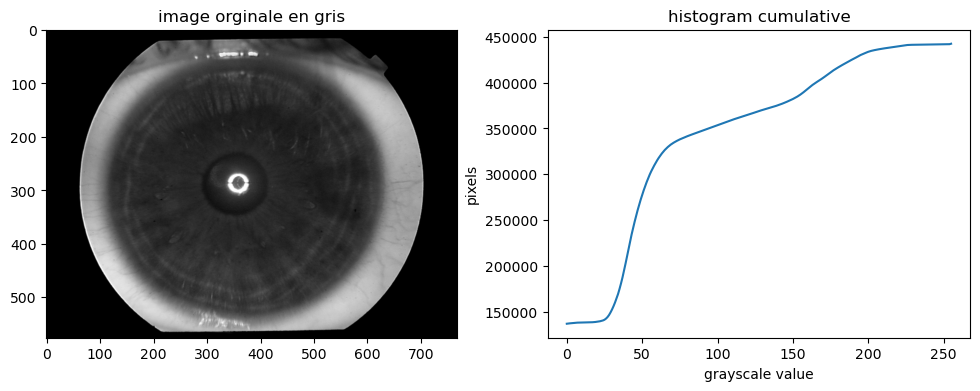

In [6]:
_, axis = plt.subplots(ncols=2, figsize=(12, 4))
axis[0].imshow(img, cmap=plt.get_cmap('gray'))
axis[1].set_title('histogram cumulative')
axis[0].set_title('image orginale en gris')
cdf = cumsum(hist)
plt.plot(np.arange(0,256),cdf)
plt.xlabel("grayscale value")
plt.ylabel("pixels")
axis[1].plot()
plt.show()

## L’histogramme cumulé normalisé d'une image:

This transformation is done simply using the rule of three: the value of each pixel is replaced by the result of the formula below.
Cette transformation se fait simplement à l’aide de la règle de trois : la valeur de chaque pixel est remplacée par le résultat de la formule ci-dessous.



 $$ S_k = \sum_{j=0}^{k}\frac{n_j}{N} = \frac{cdf - cdf_{min} * 255}{cdf_{max} - cdf_{min} }$$
 where $S_k$ and cdf denote the intensities of the pixel with coordinates (x,y) respectively in the misexposed image and the new image.
 
 où $S_k$ et cdf  désignent les intensités du pixel de coordonnées (x,y) respectivement dans l'image mal exposée et la nouvelle image.

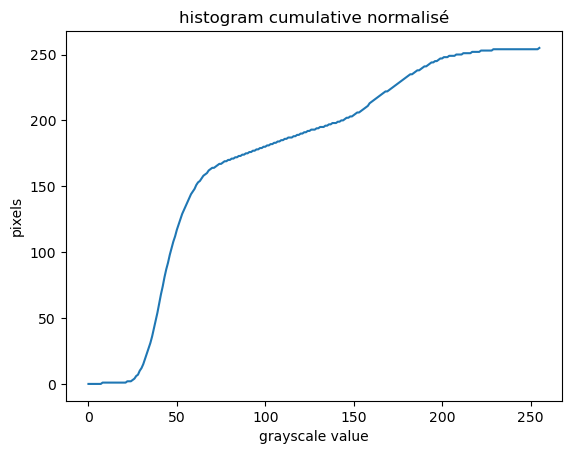

In [7]:
nj = (cdf - cdf.min()) * 255
N = cdf.max() - cdf.min()
# re-normalize the cumsum
cdf_normalized = nj / N
# cast it back to uint8 since we can't use floating point values in images
cdf_normalized= cdf_normalized.astype('uint8')
plt.plot(cdf_normalized)
plt.title('histogram cumulative normalisé')
plt.xlabel("grayscale value")
plt.ylabel("pixels")
plt.show()

## Image and histogram after adjustment/ image et histogramme aprés adjustement :

In [8]:
# get the value from cumulative sum for every index in flat, and set that as img_new
img_new = cdf_normalized[img]

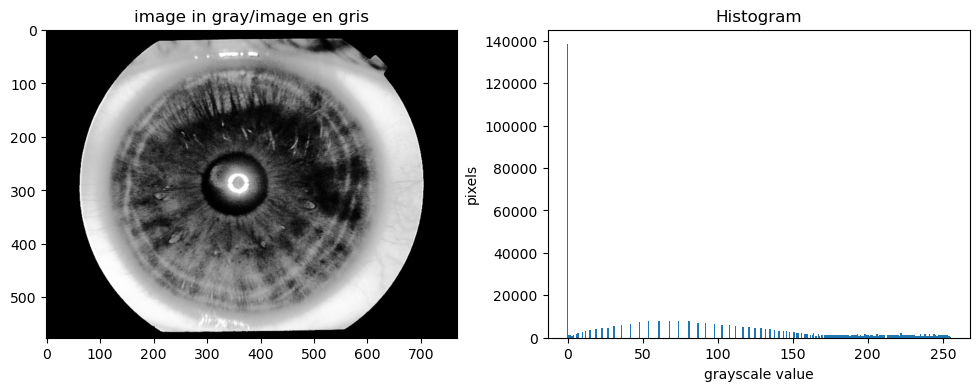

In [9]:
_, axis = plt.subplots(ncols=2, figsize=(12, 4))
axis[0].imshow(img_new, cmap=plt.get_cmap('gray'))
axis[1].set_title('Histogram')
axis[0].set_title('image in gray/image en gris')
hist=Hist(img_new)
#affichage de l'histogramme a l'haide de matplotlib
plt.bar(np.arange(0,256), hist,width = 0.99)
plt.xlabel("grayscale value")
plt.ylabel("pixels")
axis[1].plot()
plt.show()

## The image before and after equalization /L'image avant et aprés egalisation

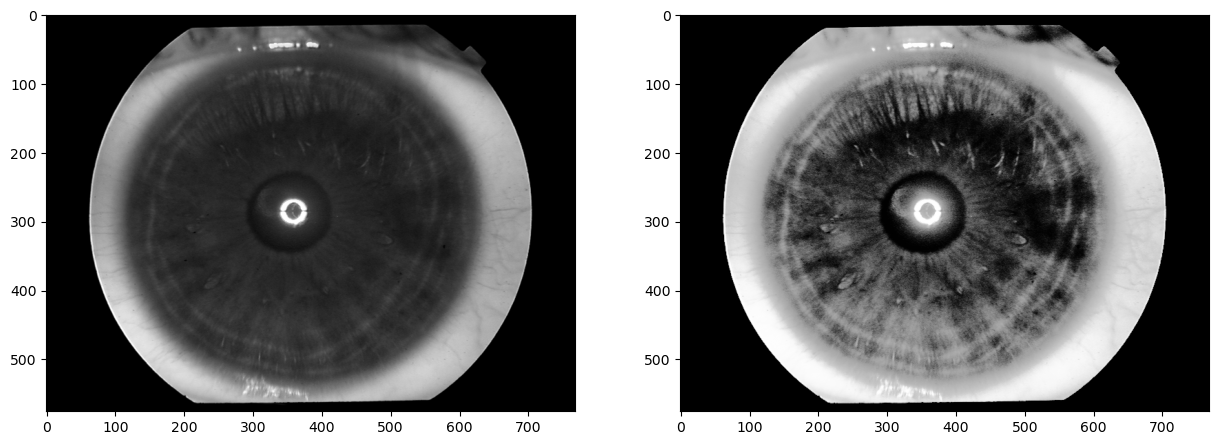

In [10]:
# put array back into original shape since we flattened it
img_new = np.reshape(img_new, img.shape)
# set up side-by-side image display
fig = plt.figure()
fig.set_figheight(15)
fig.set_figwidth(15)
fig.add_subplot(1,2,1)
plt.imshow(img, cmap='gray')
fig.add_subplot(1,2,2)
plt.imshow(img_new, cmap='gray')
plt.show(block=True)

#### save the image / Enregister l'image 

In [11]:
cv.imwrite('contrast.png',img_new)

True

#### thats all :)